## Tomato Pollination: Pepper 0

In [1]:
# def parse_obj_to_input_with_commas(obj_filename):
#     nodes = []
#     edges = []

#     # Read obj file
#     with open(obj_filename, "r") as f:
#         for line in f:
#             parts = line.strip().split()
#             if not parts:
#                 continue
#             if parts[0] == "v":  # Node line
#                 nodes.append([float(x) for x in parts[1:4]])
#             elif parts[0] == "l":  # Edge line
#                 edges.append([int(x) for x in parts[1:]])

#     # Write to input.txt with commas
#     out_filename=obj_filename.replace(".obj", ".txt")
#     with open(out_filename, "w") as f:
#         f.write("*Nodes\n")
#         for (x, y, z) in nodes:
#             f.write(f"{x}, {y}, {z}\n")

#         f.write("*Edges\n")
#         for (n1, n2) in edges:
#             f.write(f"{n1}, {n2}\n")

#     return out_filename

# # Run for all files in the directory
# directory = "../tests/resources/tomato_pollination/plants/"
# import os
# for filename in os.listdir(directory):
#     if filename.endswith(".obj"):
#         parse_obj_to_input_with_commas(os.path.join(directory, filename))



In [2]:
import numpy as np
import dismech
import os

plant_name = "pepper0"

position = "1"

geom = dismech.GeomParams(
    rod_r0=0.03,
    shell_h=0.0,
)

material = dismech.Material(density=1100,
                            youngs_rod=2.16e7,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

dyn_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=True,   # no twisting
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-3,
                                  max_iter=50,
                                  total_time=5,
                                  plot_step=100,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2
                                  )

env = dismech.Environment()
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
env.add_force('damping', eta=100)

input_txt = os.path.join('../tests/resources/tomato_pollination/plants/', f"{plant_name}.txt")
geo = dismech.Geometry.from_txt(input_txt)

robot = dismech.SoftRobot(geom, material, geo, dyn_sim, env)

### Move the stem: Moving BC

In [3]:
# # --- pick the main grip node robustly ---
# grasping_point = np.array([
#       1.1120794,
#       0.0663341,
#       0.3889156
#     ])

main_grip = [17]

print("Main grip node:", main_grip)
#82

# other_grip_nodes_below = np.array([1, 5, 8, 13], dtype=int)
# other_grip_nodes_above = np.array([57, 47, 44, 33, 28, 21], dtype=int)
# other_grip_nodes_below = []
 # all nodes except main grip node should be in this array
other_grip_nodes_below = np.arange(1, robot.n_nodes, dtype=int).tolist()
other_grip_nodes_below.remove(main_grip[0])
other_grip_nodes_above = []

print("Other grip nodes below (should be all except main):", other_grip_nodes_below)

Main grip node: [17]
Other grip nodes below (should be all except main): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174]


In [4]:
base_nodes = np.where((robot.state.q[robot.node_dof_indices].reshape(-1, 3)[:, 2]) < 0.22)[0] # fixed base
# remove any base nodes from other_grip_nodes_below (except 1)
other_grip_nodes_below = [node for node in other_grip_nodes_below if node not in base_nodes or node == 1]
print("Base nodes:", base_nodes)
print("Other grip nodes below after removing base nodes (except 1):", other_grip_nodes_below)
# Fix only main_grip and base nodes
robot = robot.fix_nodes(np.unique(np.r_[main_grip, base_nodes]))

Base nodes: [0 1 2 3]
Other grip nodes below after removing base nodes (except 1): [1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174]


In [5]:
# ----- once, before simulation -----
all_grip_nodes = np.r_[main_grip, other_grip_nodes_below, other_grip_nodes_above].astype(int)

xyz0 = robot.state.q[robot.node_dof_indices].reshape(-1, 3).copy()
x0 = xyz0[all_grip_nodes, 0].copy()          # initial x of all prescribed nodes
prev_target_x = x0.copy()                     # last absolute target (starts at initial)

# (Optional) precompute amplitude scalings from *initial* geometry
def build_amps_from_xyz0(xyz0, main_grip, all_grip_nodes, A_main):
    amps = np.empty(all_grip_nodes.size, float)
    amps[0] = A_main  # main_grip
    # below group
    below = np.array(other_grip_nodes_below, dtype=int)
    if below.size:
        ref = below[0]
        L = max(np.linalg.norm(xyz0[main_grip]-xyz0[ref]), 1e-12)
        for j, node in enumerate(below, start=1):  # start=1 because 0 is main_grip
            amps[j] = A_main * (np.linalg.norm(xyz0[ref]-xyz0[node]) / L)
    # above group
    above = np.array(other_grip_nodes_above, dtype=int)
    if above.size:
        ref = above[0]
        offset = 1 + below.size
        L = max(np.linalg.norm(xyz0[main_grip]-xyz0[ref]), 1e-12)
        for j, node in enumerate(above, start=offset):
            amps[j] = A_main * (np.linalg.norm(xyz0[ref]-xyz0[node]) / L)
    return amps

A_main = 0.4094e-2  # m at main_grip
freq   = 1.3    # Hz
amps   = build_amps_from_xyz0(xyz0, main_grip, all_grip_nodes, A_main)

print("Amplitudes (m):", amps)

def shake_distributed(robot, t: float):
    # absolute target centered at initial pose
    target_x = x0 + amps * np.sin(2*np.pi*freq*t)

    # INCREMENT ONLY: avoids velocity spikes and keeps symmetry
    delta_x = target_x - prev_target_x
    prev_target_x[:] = target_x

    return robot.move_nodes(all_grip_nodes, delta_x.reshape(-1,1).flatten(), axis=0)

print("grasping points:", all_grip_nodes)

Amplitudes (m): [0.004094   0.         0.01150699 0.00129464 0.00672713 0.01161572
 0.002047   0.00672713 0.01564316 0.01224785 0.00697183 0.00330069
 0.01515334 0.01204082 0.00743712 0.01409312 0.01235005 0.007928
 0.0047568  0.00501411 0.01435822 0.01271779 0.00578979 0.00586172
 0.0084895  0.00564319 0.01348537 0.01245141 0.01011143 0.00924555
 0.00666455 0.01388343 0.01193596 0.01161571 0.00977429 0.00823902
 0.00782158 0.014329   0.01193596 0.01006991 0.00960129 0.0084895
 0.01193596 0.01481779 0.00938053 0.01545452 0.012282   0.01248502
 0.01545451 0.01172343 0.01204082 0.0125853  0.01556259 0.02034681
 0.01217922 0.01537296 0.02030558 0.01534568 0.02089545 0.01518096
 0.01577651 0.02059245 0.01501444 0.01961279 0.01582955 0.01580305
 0.01582955 0.016979   0.01668022 0.01922437 0.01873872 0.01844573
 0.01807862 0.01758515 0.01849111 0.02185598 0.01939796 0.02262838
 0.02024358 0.02317725 0.02123362 0.02214169 0.023907   0.02430678
 0.02402937 0.02409902 0.02896342 0.02990302 0.02

In [6]:
stepper = dismech.ImplicitEulerTimeStepper(robot)
stepper.before_step = shake_distributed

### Simulate

In [7]:
# simulate
robots = stepper.simulate()

qs = np.stack([robot.state.q for robot in robots])

iter: 1, error: 3361.518
iter: 2, error: 4.067
current_time:  0.001
iter: 1, error: 3363.295
iter: 2, error: 4.531
current_time:  0.002
iter: 1, error: 3361.662
iter: 2, error: 4.390
current_time:  0.003
iter: 1, error: 3360.880
iter: 2, error: 4.377
current_time:  0.004
iter: 1, error: 3360.097
iter: 2, error: 4.482
current_time:  0.005
iter: 1, error: 3359.250
iter: 2, error: 4.722
current_time:  0.006
iter: 1, error: 3358.290
iter: 2, error: 5.139
current_time:  0.007
iter: 1, error: 3357.186
iter: 2, error: 5.762
current_time:  0.008
iter: 1, error: 3355.920
iter: 2, error: 6.577
current_time:  0.009000000000000001
iter: 1, error: 3354.478
iter: 2, error: 7.492
current_time:  0.01
iter: 1, error: 3352.841
iter: 2, error: 8.368
current_time:  0.011
iter: 1, error: 3350.993
iter: 2, error: 9.041
current_time:  0.012
iter: 1, error: 3348.917
iter: 2, error: 9.367
current_time:  0.013000000000000001
iter: 1, error: 3346.600
iter: 2, error: 9.267
current_time:  0.014
iter: 1, error: 334

### Plotting

In [8]:
t = np.arange(robot.sim_params.total_time, step=robot.sim_params.dt)
options = dismech.AnimationOptions(title=plant_name, plot_step=robot.sim_params.plot_step)

fig = dismech.get_interactive_animation_plotly(robot, t, qs , options)
fig.show()

In [9]:
# # save gif
# ani = dismech.get_animation(robot, t, qs, options)
# save_path = os.path.join("tomato_results", f"{plant_name}_{position}.gif")
# ani.save(save_path)

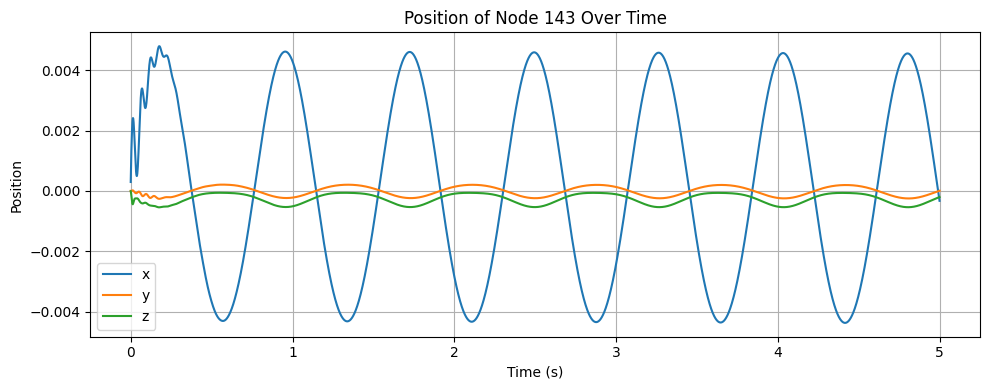

In [10]:
# plot the trajectory of the flower location
flower_node = 143  # pick a node at the flower
# flower_node = main_grip  # pick a node at the flower

import matplotlib.pyplot as plt

# Extract the DOF indices (x, y, z) of the node you want to track
flower_node_dofs = robot.map_node_to_dof(flower_node)  # e.g., [ix, iy, iz]

# Extract position of that node across all timesteps
logged = qs[:, flower_node_dofs].squeeze()  # shape (n_timesteps, 3)

# remove value at t=0
logged -= robot.nodes[flower_node]

# Plot x, y, z over time
t = np.arange(qs.shape[0]) * robot.sim_params.dt

plt.figure(figsize=(10, 4))
plt.plot(t, logged[:, 0], label='x')
plt.plot(t, logged[:, 1], label='y')
plt.plot(t, logged[:, 2], label='z')
plt.xlabel('Time (s)')
plt.ylabel('Position')
plt.title(f'Position of Node {flower_node} Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
import numpy as np
from scipy.signal import hilbert, detrend, find_peaks

def avg_cycle_amplitude_hilbert(x: np.ndarray) -> float:
    """
    Robust average oscillation amplitude using the analytic-signal envelope.
    Returns the median envelope value (less sensitive to outliers).
    """
    x = np.asarray(x).ravel()
    x = detrend(x)  # remove slow drift
    envelope = np.abs(hilbert(x))
    # Use median to resist occasional spikes; mean is also fine.
    return float(np.median(envelope))
# amplitude of flower node motion
amp_x_flower_hilbert = avg_cycle_amplitude_hilbert(logged[:, 0]) # hilbert-based amplitude
amp_x_flower_peak = (np.max(logged[:, 0]) - np.min(logged[:, 0])) / 2.0 # peak-to-peak amplitude
print(f"Amplitude of flower node {flower_node} motion in x (peak-to-peak): {amp_x_flower_peak:.4f} m")
print(f"Amplitude of flower node {flower_node} motion in x (hilbert): {amp_x_flower_hilbert:.4f} m")

Amplitude of flower node 143 motion in x (peak-to-peak): 0.0046 m
Amplitude of flower node 143 motion in x (hilbert): 0.0045 m


### Save data for rendering

In [12]:
# from dismech.logging import logDataForRendering
# from dismech.logging import export_rod_shell_data, export_parachute_data

# rod_data, shell_data = logDataForRendering(qs, t.reshape(-1, 1), robot, len(t), robot.sim_params.static_sim, robot.map_node_to_dof, log_step=10)

# js_file = os.path.join("tomato_results", f"{plant_name}_{position}.js")

# export_parachute_data(qs, geo.rod_edges, robot,
#                           rod_js=js_file,
#                           scaleFactor=100)

### Estimated values of parameters

In [13]:
# L = 0.292 # m
# r0 = 0.0059 # m

# delta = 0.054 # m # delta = PL^3/(3EI)
# P = 0.02*9.81 # N

# K = P/delta # effective stiffness

# I = np.pi * r0**4 / 4
# E = P*(L**3) / (3 * I * delta)

# print("E:", E)

# f = 1.38 # Hz
# TP = 0.725 # s

# omega = 2 * np.pi * f
# m_eff = K / omega**2
# print("m_eff:", m_eff)

# # estimate density
# V = np.pi * r0**2 * L
# rho = m_eff / V
# print("rho:", rho)